In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

## direct wrapper for numpy random generator, use numpy itself if you're comfortable
## and want more control over the distribution
def gaussian_cloud(dimension=3, samples=5000):
    return rng.multivariate_normal(np.zeros((dimension)), np.identity(dimension), (samples))


In [ ]:
### From Claude ###

from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Protocol, Tuple, Iterator
import numpy as np


@dataclass
class BoundingBox:
    mins: np.ndarray
    maxs: np.ndarray

    @classmethod
    def from_points(cls, points: np.ndarray) -> "BoundingBox":
        return cls(points.min(axis=0).copy(), points.max(axis=0).copy())

    def split(self, axis: int, value: float) -> Tuple["BoundingBox", "BoundingBox"]:
        left_maxs = self.maxs.copy(); left_maxs[axis] = value
        right_mins = self.mins.copy(); right_mins[axis] = value
        return BoundingBox(self.mins.copy(), left_maxs), BoundingBox(right_mins, self.maxs.copy())

    @property
    def extent(self) -> np.ndarray:
        return self.maxs - self.mins

    @property
    def volume(self):
        return np.prod(self.maxs - self.mins)



@dataclass
class KDNode:
    bbox: BoundingBox        # "cell" box, inherited by halving the parent's box
    indices: np.ndarray      # indices into the original points array
    depth: int
    axis: Optional[int] = None
    split_value: Optional[float] = None
    left: Optional["KDNode"] = None
    right: Optional["KDNode"] = None

    @property
    def is_leaf(self) -> bool:
        return self.left is None and self.right is None

    def tight_bbox(self, points: np.ndarray) -> BoundingBox:
        return BoundingBox.from_points(points[self.indices])

    def leaves(self) -> Iterator["KDNode"]:
        if self.is_leaf:
            yield self
        else:
            yield from self.left.leaves()
            yield from self.right.leaves()


class SplitStrategy(Protocol):
    def should_stop(self, points, indices, depth) -> bool: ...
    def choose_split(self, points, indices, bbox, depth) -> Tuple[int, float]: ...


def build_kdtree(points, strategy: SplitStrategy, indices=None, bbox=None, depth=0) -> KDNode:
    points = np.asarray(points, dtype=float)
    if indices is None:
        indices = np.arange(len(points))
    if bbox is None:
        bbox = BoundingBox.from_points(points)

    if strategy.should_stop(points, indices, depth):
        return KDNode(bbox=bbox, indices=indices, depth=depth)

    axis, value = strategy.choose_split(points, indices, bbox, depth)
    coords = points[indices, axis]
    left_mask = coords <= value
    left_idx, right_idx = indices[left_mask], indices[~left_mask]

    if len(left_idx) == 0 or len(right_idx) == 0:   # degenerate split guard
        return KDNode(bbox=bbox, indices=indices, depth=depth)

    left_bbox, right_bbox = bbox.split(axis, value)
    node = KDNode(bbox=bbox, indices=indices, depth=depth, axis=axis, split_value=value)
    node.left = build_kdtree(points, strategy, left_idx, left_bbox, depth + 1)
    node.right = build_kdtree(points, strategy, right_idx, right_bbox, depth + 1)
    return node

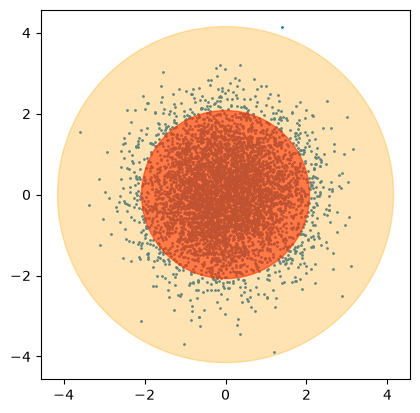

In [14]:
fig, ax = plt.subplots()
ax.set_box_aspect(1)
cloud = gaussian_cloud(dimension=2)

scale = abs(cloud).max()
ax.set_xlim(-1.1*scale,1.1*scale)
ax.set_ylim(-1.1*scale,1.1*scale)
ax.scatter(*cloud.T,s=1)

c1 = plt.Circle((0, 0), radius=scale*0.5, color='red', alpha=0.6, fill=True)
c2 = plt.Circle((0, 0), radius=scale, color='orange', alpha=0.3, fill=True)
ax.add_patch(c1)
ax.add_patch(c2)